In [2]:
from galaxy_datasets import gz_candels 
    
catalog, label_cols = gz_candels(
        root='.tmp/',
        train=True,
        download=True,
)


In [3]:
from galaxy_datasets.pytorch.galaxy_dataset import GalaxyDataset
gzdataset = GalaxyDataset(
    catalog,
    label_cols=catalog.columns.tolist()[:-2],  # all columns except 'image_path'
    transform=None,
)

[27. 24. 21. 17. 10.  0. 20.  4.  1.  0.  4.  2. 12.  1.  0.  4.  0.  0.
  0.  4.  0.  4.  0.  0.  0.  0.  0.  0.  0.  0.  0.  3.  1.  0. 21.  1.
  6. 23.]
(424, 424)


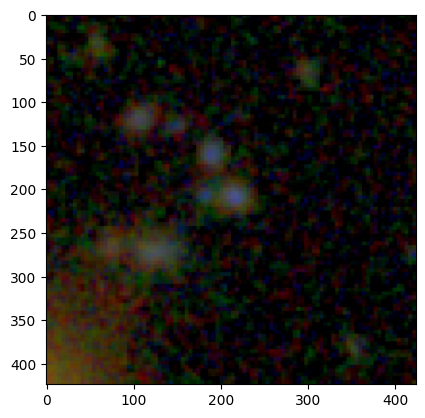

In [4]:
import numpy as np
import matplotlib.pyplot as plt
img, labels = gzdataset[np.random.randint(len(gzdataset))]
plt.imshow(img)
print(labels)
print(img.size)

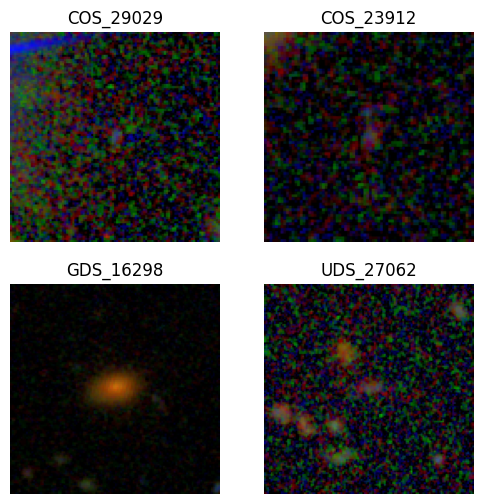

In [13]:
from ml_sandbox.dataset import show_sample_images
for i in range(3,4):
    show_sample_images(gzdataset, num_images=i+1)

In [14]:
from ml_sandbox.models import PCARandomForestPipeline
from ml_sandbox.train_eval import train_eval_loop_rf

In [ ]:
model = PCARandomForestPipeline(n_pca_comp=100, n_trees=50, random_state=42)
train_eval_loop_rf(model, gzdataset, label_cols, num_epochs=5)